<a href="https://colab.research.google.com/github/rsmani84/Conductometric-Titration-of-simple-acid-Vs-Base/blob/main/Interactive_Polymer_Molecular_Weight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install required package
!pip install reportlab

import numpy as np
import matplotlib.pyplot as plt
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table
from reportlab.lib import styles
from reportlab.lib.pagesizes import letter
import os

# --- STUDENT INPUT ---

polymer_name = input("Enter polymer name (e.g., Polystyrene, PVC, PMMA): ")

t0 = float(input("Enter solvent flow time t0 (s): "))
n = int(input("Enter number of concentration readings: "))

concentration = []
flow_time = []

for i in range(n):
    c = float(input(f"Enter concentration {i+1} (g/dL): "))
    t = float(input(f"Enter flow time for concentration {i+1} (s): "))
    concentration.append(c)
    flow_time.append(t)

concentration = np.array(concentration)
flow_time = np.array(flow_time)

# --- MARK–HOUWINK DATABASE ---

mark_houwink = {
    "polystyrene": {"K": 1.1e-4, "a": 0.73},
    "pmma": {"K": 5.5e-4, "a": 0.76},
    "pvc": {"K": 6.3e-4, "a": 0.62},
    "polyethylene": {"K": 6.2e-4, "a": 0.70},
    "polypropylene": {"K": 1.5e-4, "a": 0.75}
}

polymer_key = polymer_name.lower()

if polymer_key in mark_houwink:
    K = mark_houwink[polymer_key]["K"]
    a = mark_houwink[polymer_key]["a"]
else:
    print("\nPolymer not in database → Molecular weight will not be calculated.")
    K = None

# --- CALCULATIONS ---

relative_viscosity = flow_time / t0
specific_viscosity = relative_viscosity - 1
reduced_viscosity = specific_viscosity / concentration

coeffs = np.polyfit(concentration, reduced_viscosity, 1)
intrinsic_viscosity = coeffs[1]

if K is not None:
    Mv = (intrinsic_viscosity / K) ** (1 / a)

# --- PRINT OUTPUT ---

print("\n==============================")
print(f"Polymer: {polymer_name}")
print("==============================")

for i in range(n):
    print(f"{concentration[i]:.3f}  {flow_time[i]:.3f}  {relative_viscosity[i]:.3f}  {specific_viscosity[i]:.3f}  {reduced_viscosity[i]:.3f}")

print(f"\nIntrinsic viscosity [η] = {intrinsic_viscosity:.4f} dL/g")

if K is not None:
    print(f"Molecular Weight (Mv) = {Mv:.2f}")

# --- GRAPH SAVE ---

graph_filename = "viscosity_graph.png"

plt.plot(concentration, reduced_viscosity, 'o', label="Experimental data")
plt.plot(concentration, np.polyval(coeffs, concentration), '-', label="Best fit line")
plt.xlabel("Concentration (g/dL)")
plt.ylabel("Reduced Viscosity (ηsp/C)")
plt.title(f"{polymer_name} – Molecular Weight Determination")
plt.legend()
plt.grid()
plt.savefig(graph_filename)
plt.close()

# --- CREATE PDF ---

pdf_filename = f"{polymer_name}_report.pdf"

doc = SimpleDocTemplate(pdf_filename, pagesize=letter)
styles_list = styles.getSampleStyleSheet()

content = []

content.append(Paragraph(f"<b>Polymer:</b> {polymer_name}", styles_list['Normal']))
content.append(Spacer(1, 10))

content.append(Paragraph("<b>Experimental Data</b>", styles_list['Heading2']))
content.append(Spacer(1, 10))

# Table
table_data = [["Conc", "Flow time", "Rel visc", "Spec visc", "Red visc"]]

for i in range(n):
    table_data.append([
        f"{concentration[i]:.3f}",
        f"{flow_time[i]:.3f}",
        f"{relative_viscosity[i]:.3f}",
        f"{specific_viscosity[i]:.3f}",
        f"{reduced_viscosity[i]:.3f}"
    ])

table = Table(table_data)
content.append(table)

content.append(Spacer(1, 20))

content.append(Paragraph(f"<b>Intrinsic viscosity [η]:</b> {intrinsic_viscosity:.4f} dL/g", styles_list['Normal']))

if K is not None:
    content.append(Paragraph(f"<b>K:</b> {K}, <b>a:</b> {a}", styles_list['Normal']))
    content.append(Paragraph(f"<b>Molecular Weight (Mv):</b> {Mv:.2f}", styles_list['Normal']))

content.append(Spacer(1, 20))

# Add Graph
if os.path.exists(graph_filename):
    content.append(Paragraph("<b>Graph</b>", styles_list['Heading2']))
    content.append(Spacer(1, 10))
    content.append(Image(graph_filename, width=400, height=300))

doc.build(content)

print(f"\n✅ PDF generated successfully: {pdf_filename}")

Enter Student Name: Subramanian R
Enter Register Number: FET35
Enter polymer name: PVC
Enter solvent flow time t0 (s): 50
Enter number of readings: 6
Enter concentration 1: 0.1
Enter flow time 1: 56
Enter concentration 2: 0.2
Enter flow time 2: 63
Enter concentration 3: 0.3
Enter flow time 3: 72
Enter concentration 4: 0.4
Enter flow time 4: 82
Enter concentration 5: 0.5
Enter flow time 5: 93
Enter concentration 6: 0.6
Enter flow time 6: 109

Entered Data:
Index   Conc      Flow Time
1       0.1       56.0
2       0.2       63.0
3       0.3       72.0
4       0.4       82.0
5       0.5       93.0
6       0.6       109.0

Edit any value? (yes/no): yes
Enter index to edit: 6
Edit (c) concentration or (t) flow time?: 110
Invalid option

Entered Data:
Index   Conc      Flow Time
1       0.1       56.0
2       0.2       63.0
3       0.3       72.0
4       0.4       82.0
5       0.5       93.0
6       0.6       109.0

Edit any value? (yes/no): no

===== RESULTS =====
C     t     Rel    Spec  

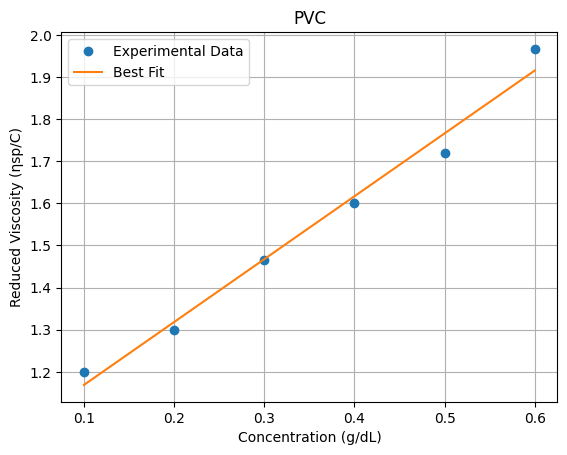


✅ FINAL REPORT GENERATED: Subramanian R_Viscometry_Report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# Install required package (run once in Colab/Jupyter)
!pip install reportlab

import numpy as np
import matplotlib.pyplot as plt
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table
from reportlab.lib import styles
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
import os

# --- STUDENT DETAILS ---

student_name = input("Enter Student Name: ")
reg_no = input("Enter Register Number: ")

polymer_name = input("Enter polymer name: ")
t0 = float(input("Enter solvent flow time t0 (s): "))
n = int(input("Enter number of readings: "))

concentration = []
flow_time = []

for i in range(n):
    c = float(input(f"Enter concentration {i+1}: "))
    t = float(input(f"Enter flow time {i+1}: "))
    concentration.append(c)
    flow_time.append(t)

# --- EDIT OPTION ---

while True:
    print("\nEntered Data:")
    print("Index   Conc      Flow Time")
    for i in range(n):
        print(f"{i+1}       {concentration[i]}       {flow_time[i]}")

    choice = input("\nEdit any value? (yes/no): ")

    if choice.lower() != "yes":
        break

    idx = int(input("Enter index to edit: ")) - 1

    if 0 <= idx < n:
        edit_choice = input("Edit (c) concentration or (t) flow time?: ")

        if edit_choice.lower() == 'c':
            concentration[idx] = float(input("New concentration: "))
        elif edit_choice.lower() == 't':
            flow_time[idx] = float(input("New flow time: "))
        else:
            print("Invalid option")
    else:
        print("Invalid index")

# Convert to numpy
concentration = np.array(concentration)
flow_time = np.array(flow_time)

# --- MARK–HOUWINK DATABASE ---

mark_houwink = {
    "polystyrene": {"K": 1.1e-4, "a": 0.73},
    "pmma": {"K": 5.5e-4, "a": 0.76},
    "pvc": {"K": 6.3e-4, "a": 0.62},
}

polymer_key = polymer_name.lower()

if polymer_key in mark_houwink:
    K = mark_houwink[polymer_key]["K"]
    a = mark_houwink[polymer_key]["a"]
else:
    print("Polymer not in database")
    K = None

# --- CALCULATIONS ---

rel = flow_time / t0
spec = rel - 1
red = spec / concentration

coeffs = np.polyfit(concentration, red, 1)
intrinsic = coeffs[1]

if K:
    Mv = (intrinsic / K) ** (1 / a)

# --- DISPLAY RESULTS ---

print("\n===== RESULTS =====")
print("C     t     Rel    Spec    Red")

for i in range(n):
    print(f"{concentration[i]:.3f}  {flow_time[i]:.3f}  {rel[i]:.3f}  {spec[i]:.3f}  {red[i]:.3f}")

print(f"\nIntrinsic viscosity = {intrinsic:.4f}")

if K:
    print(f"Molecular weight (Mv) = {Mv:.2f}")

# --- GRAPH ---

graph_file = "graph.png"

plt.figure()
plt.plot(concentration, red, 'o', label="Experimental Data")
plt.plot(concentration, np.polyval(coeffs, concentration), '-', label="Best Fit")
plt.xlabel("Concentration (g/dL)")
plt.ylabel("Reduced Viscosity (ηsp/C)")
plt.title(polymer_name)
plt.legend()
plt.grid()

plt.savefig(graph_file)
plt.show()
plt.close()

# --- PDF REPORT ---

pdf_file = f"{student_name}_Viscometry_Report.pdf"

doc = SimpleDocTemplate(pdf_file, pagesize=letter)
style = styles.getSampleStyleSheet()

# Styles
center_style = ParagraphStyle(name='Center', alignment=TA_CENTER)
justify_style = ParagraphStyle(
    name='Justify',
    alignment=TA_JUSTIFY,
    fontName='Helvetica-Bold',
    fontSize=10,
    leading=14
)

content = []

# --- INSTITUTION HEADER ---

content.append(Paragraph(
"<b>SRM Institute of Science and Technology, Tiruchirappalli</b>",
center_style
))
content.append(Spacer(1,10))

content.append(Paragraph(
"<b>Faculty of Engineering and Technology</b>",
center_style
))

content.append(Paragraph(
"<b>Department of Chemistry</b>",
center_style
))

content.append(Spacer(1,15))

content.append(Paragraph(
"<b>MOLECULAR WEIGHT DETERMINATION OF POLYMER USING VISCOMETRY</b>",
style['Heading1']
))

content.append(Spacer(1,20))

# --- STUDENT DETAILS ---

content.append(Paragraph(f"<b>Name:</b> {student_name}", style['Normal']))
content.append(Paragraph(f"<b>Register Number:</b> {reg_no}", style['Normal']))
content.append(Spacer(1,10))

# --- EXPERIMENT DETAILS ---

content.append(Paragraph("<b>Experiment Details</b>", style['Heading2']))
content.append(Paragraph(f"Polymer: {polymer_name}", style['Normal']))
content.append(Paragraph(f"Solvent flow time (t₀): {t0} s", style['Normal']))
content.append(Spacer(1,10))

# --- TABLE ---

table_data = [["Conc", "Flow time", "Rel", "Spec", "Red"]]

for i in range(n):
    table_data.append([
        f"{concentration[i]:.3f}",
        f"{flow_time[i]:.3f}",
        f"{rel[i]:.3f}",
        f"{spec[i]:.3f}",
        f"{red[i]:.3f}"
    ])

content.append(Table(table_data))
content.append(Spacer(1,15))

# --- THEORY ---

content.append(Paragraph("<b>Theory & Formula</b>", style['Heading2']))

content.append(Paragraph(
"<b>Relative viscosity (ηr = t / t₀):</b> Ratio of solution flow time to solvent flow time.",
style['Normal']
))

content.append(Paragraph(
"<b>Specific viscosity (ηsp = ηr − 1):</b> Increase in viscosity due to polymer.",
style['Normal']
))

content.append(Paragraph(
"<b>Reduced viscosity (ηsp / C):</b> Normalized viscosity with concentration.",
style['Normal']
))

content.append(Paragraph(
"<b>Intrinsic viscosity [η]:</b> Obtained from graph intercept at zero concentration.",
style['Normal']
))

content.append(Paragraph(
"<b>Mark–Houwink Equation:</b> [η] = K Mᵃ",
style['Normal']
))

content.append(Paragraph(
"<b>α (alpha):</b> Indicates polymer shape. α ≈ 0.5 (coil), α > 0.5 (expanded), α ≈ 1 (rigid).",
style['Normal']
))

content.append(Spacer(1,15))

# --- RESULTS ---

content.append(Paragraph("<b>Results</b>", style['Heading2']))
content.append(Paragraph(f"Intrinsic viscosity = {intrinsic:.4f}", style['Normal']))

if K:
    content.append(Paragraph(f"K = {K}, α = {a}", style['Normal']))
    content.append(Paragraph(f"Molecular Weight (Mv) = {Mv:.2f}", style['Normal']))

content.append(Spacer(1,15))

# --- CONCLUSION (JUSTIFIED + BOLD) ---

content.append(Paragraph(
"This experiment was performed using Google Colab, which eliminates the need for physical instruments "
"and enables students from various disciplines (B.Tech - AIML, AI, Mechanical, EEE, Food Tech, ECE-DS, Biotechnology) to understand polymer characterization "
"through computational methods. This approach enhances visualization, improves accuracy, and introduces students "
"to modern data-driven scientific techniques.",
justify_style
))

content.append(Spacer(1,15))

# --- GRAPH ---

content.append(Paragraph("<b>Graph</b>", style['Heading2']))
content.append(Image(graph_file, width=400, height=300))

doc.build(content)

print(f"\n✅ FINAL REPORT GENERATED: {pdf_file}")

# --- DOWNLOAD (COLAB) ---
try:
    from google.colab import files
    files.download(pdf_file)
except:
    print("👉 Open file from your system folder")
